# Role Analysis
This notebook identifies top skills required for top roles, i.e., the roles that have the highest no. of job_postings and the salary comparison per role

Load Dataframe

In [1]:
import pandas as pd

# Loading the cleaned job dataset 
# (.pkl format is imported since it retains python objects like list and idctionaries unlike .csv wich converts them to string)
df = pd.read_pickle("../data/processed/cleaned_jobs.pkl")

df.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_id
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",[Work Nearby],Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,[],{},J-e02c886264ce
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",[BeBee México],Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"[nosql, power bi, python, r, sql, tableau]","{'analyst_tools': ['power bi', 'tableau'], 'pr...",J-64833455be38
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",[LinkedIn],Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"[airflow, azure, c#, dax, docker, jenkins, kub...","{'analyst_tools': ['dax'], 'cloud': ['azure'],...",J-c8afb754b830
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",[Diversity.com],Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"[aws, c++, java, keras, matlab, python, pytorc...","{'cloud': ['aws'], 'libraries': ['keras', 'pyt...",J-6b595ba75824
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",[Clearance Jobs],Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,NaN,NaN,NaN,Kristina Daniel,"[ansible, aws, bash, git, gitlab, jenkins, ora...","{'cloud': ['aws', 'oracle'], 'other': ['ansibl...",J-88bb30c3cf7d


In [2]:
# Identifying the top 3 most frequent job roles
top_roles = df['job_title_short'].value_counts().head(3).index
top_roles

Index(['Data Analyst', 'Data Engineer', 'Data Scientist'], dtype='str', name='job_title_short')

In [3]:
# Filtering dataset to include only the top job roles
df_roles = df[df['job_title_short'].isin(top_roles)].copy()

# Removing rows where skill data is missing
df_roles = df_roles.dropna(subset=['job_skills'])

# Expanding list of skills into individual rows
# Each row will now represent one skill per job posting
df_roles = df_roles.explode('job_skills')

df_roles

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_id
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",[BeBee México],Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,nosql,"{'analyst_tools': ['power bi', 'tableau'], 'pr...",J-64833455be38
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",[BeBee México],Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,power bi,"{'analyst_tools': ['power bi', 'tableau'], 'pr...",J-64833455be38
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",[BeBee México],Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,python,"{'analyst_tools': ['power bi', 'tableau'], 'pr...",J-64833455be38
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",[BeBee México],Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,r,"{'analyst_tools': ['power bi', 'tableau'], 'pr...",J-64833455be38
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",[BeBee México],Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,sql,"{'analyst_tools': ['power bi', 'tableau'], 'pr...",J-64833455be38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",[melalui Recruit.net],Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,NaN,NaN,NaN,Capital One,redshift,"{'cloud': ['aws', 'azure', 'redshift', 'snowfl...",J-a94d273e8878
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",[melalui Recruit.net],Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,NaN,NaN,NaN,Capital One,shell,"{'cloud': ['aws', 'azure', 'redshift', 'snowfl...",J-a94d273e8878
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",[melalui Recruit.net],Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,NaN,NaN,NaN,Capital One,snowflake,"{'cloud': ['aws', 'azure', 'redshift', 'snowfl...",J-a94d273e8878
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",[melalui Recruit.net],Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,NaN,NaN,NaN,Capital One,spark,"{'cloud': ['aws', 'azure', 'redshift', 'snowfl...",J-a94d273e8878


## Top Skills Demand by Role

This visualization analyzes the most in-demand skills for each role by examining their relative frequency in job postings. The goal is to identify key skill requirements and compare demand patterns across roles.

- The chart is divided into separate subplots, with one panel for each role.
- Each subplot displays the top skills associated with that role using horizontal bar charts.
- Skill demand is represented as a percentage, allowing for standardized comparison.
- A consistent axis scale is applied across all subplots to ensure fair comparison between roles.

In [4]:
# Grouping data by job role and skill to calculate frequency
df_role_skills = (
    df_roles.groupby(['job_title_short', 'job_skills'])
    .size()
    .reset_index(name='count')
)

df_role_skills

,job_title_short,job_skills,count
0,Data Analyst,airflow,2000
1,Data Analyst,airtable,88
2,Data Analyst,alteryx,4569
3,Data Analyst,angular,376
4,Data Analyst,angular.js,2
...,...,...,...
706,Data Scientist,wrike,8
707,Data Scientist,wsl,31
708,Data Scientist,xamarin,5
709,Data Scientist,yarn,249


In [5]:
# Sorting skills within each role by demand (highest first)
df_top_role_skills = (
    df_role_skills
    .sort_values(['job_title_short', 'count'], ascending=[True, False])
    .groupby('job_title_short')
    .head(10)   # Select top 10 skills per role
)

# Calculating percentage share of each skill within its role
df_top_role_skills['percentage'] = (
    df_top_role_skills['count'] /
    df_top_role_skills.groupby('job_title_short')['count'].transform('sum')
) * 100

df_top_role_skills

,job_title_short,job_skills,count,percentage
189,Data Analyst,sql,92346,24.003868
58,Data Analyst,excel,66823,17.369572
154,Data Analyst,python,57150,14.855230
202,Data Analyst,tableau,46424,12.067177
147,Data Analyst,power bi,39354,10.229444
158,Data Analyst,r,29978,7.792302
170,Data Analyst,sas,13990,3.636477
149,Data Analyst,powerpoint,13816,3.591249
228,Data Analyst,word,13557,3.523926
169,Data Analyst,sap,11275,2.930756


### Plot Graph for top skills required for top roles

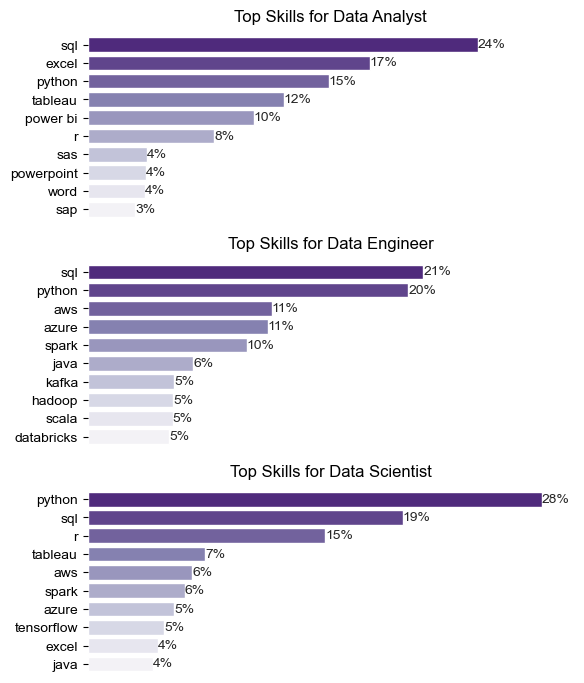

In [6]:
# Importing visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

# Defining roles and maximum value for consistent scaling
roles = top_roles
max_val = df_top_role_skills['percentage'].max()

# Creating subplots (one for each role)
fig, ax = plt.subplots(3, 1, figsize=(6, 7))

# Setting visual theme
sns.set_theme(style='ticks')

# Looping through each role to create individual charts
for i, role in enumerate(roles):
    # Filtering data for the current role
    data = df_top_role_skills[df_top_role_skills['job_title_short'] == role]
    
    # Creating horizontal bar plot
    sns.barplot(
        data=data,
        x='percentage',       # Percentage share of skill demand
        y='job_skills',       # Skills on y-axis
        hue='job_skills',     # Color differentiation (optional)
        ax=ax[i],
        palette='Purples_r',
        legend=False
    )

    # Setting title for each subplot
    ax[i].set_title(f'Top Skills for {role}', pad=10)

    # Cleaning axis labels
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')

    # Formatting x-axis as percentage
    ax[i].xaxis.set_major_formatter(PercentFormatter(xmax=100))

    # Removing x-axis ticks for cleaner look
    ax[i].set_xticks([])

    # Ensuring consistent x-axis scale across all plots
    ax[i].set_xlim(0, max_val + 2)

    # Adding percentage labels on bars
    for container in ax[i].containers:
        ax[i].bar_label(container, fmt='%.0f%%', fontsize=10)

# Removing unnecessary chart borders (spines)
sns.despine(left=True, bottom=True)

# Adjusting spacing between subplots
plt.subplots_adjust(hspace=0.4)

# Ensuring proper layout
plt.tight_layout()

In [7]:
# Mapping base roles to their corresponding senior roles
roles_map = {
    'Data Analyst': 'Senior Data Analyst',
    'Data Engineer': 'Senior Data Engineer',
    'Data Scientist': 'Senior Data Scientist'
}

# Creating a combined list of roles (both base and senior)
roles = list(roles_map.keys()) + list(roles_map.values())

roles

['Data Analyst',
 'Data Engineer',
 'Data Scientist',
 'Senior Data Analyst',
 'Senior Data Engineer',
 'Senior Data Scientist']

In [8]:
# Filtering dataset to include only base and senior roles
df_base_senior_roles = df[df['job_title_short'].isin(roles)].copy()

# Removing rows where salary information is missing
df_base_senior_roles = df_base_senior_roles.dropna(subset=['salary_year_avg'])

df_base_senior_roles

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_id
28,Data Scientist,CRM Data Specialist,"San José Province, San José, Costa Rica",[Ai-Jobs.net],Full-time,False,Costa Rica,2023-08-01 13:37:57,False,False,Costa Rica,year,109500.0,NaN,Netskope,"[excel, gdpr]","{'analyst_tools': ['excel'], 'libraries': ['gd...",J-281659ce7833
77,Data Engineer,Data Engineer,"Arlington, VA",[LinkedIn],Full-time,False,Sudan,2023-06-26 14:22:54,False,False,Sudan,year,140000.0,NaN,Intelletec,"[kubernetes, mariadb, mongodb, mysql, oracle, ...","{'analyst_tools': ['tableau'], 'cloud': ['orac...",J-1af0c5d6762a
92,Data Engineer,Remote - Data Engineer - Permanent - W2,Anywhere,[LinkedIn],Full-time,True,"Illinois, United States",2023-02-21 13:29:59,False,True,United States,year,120000.0,NaN,Apex Systems,"[python, sql]","{'programming': ['python', 'sql']}",J-7e8ae463e939
100,Data Scientist,"Data Scientist, Risk Data Mining - USDS","Mountain View, CA",[LinkedIn],Full-time,False,"California, United States",2023-07-31 13:01:18,False,True,United States,year,228222.0,NaN,TikTok,"[express, python, r, sql]","{'programming': ['python', 'r', 'sql'], 'webfr...",J-23f67234d815
109,Data Analyst,Senior Supply Chain Analytics Analyst,Anywhere,[Get.It],Full-time,True,"Illinois, United States",2023-10-12 13:02:19,False,True,United States,year,89000.0,NaN,Get It Recruit - Transportation,"[alteryx, python, r, tableau]","{'analyst_tools': ['alteryx', 'tableau'], 'pro...",J-2e93c5c88e70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785624,Data Engineer,Data Analytics Engineer (Hybrid),"Mt Prospect, IL",[Ai-Jobs.net],Full-time,False,"Illinois, United States",2023-08-31 06:02:16,False,True,United States,year,139216.0,NaN,Bosch Group,"[alteryx, go, oracle, power bi, python, qlik, ...","{'analyst_tools': ['alteryx', 'power bi', 'qli...",J-5bdcf66cf6c0
785641,Data Engineer,Data Engineer,"New York, NY",[Dice],Full-time,False,Georgia,2023-01-04 16:36:07,True,False,United States,year,150000.0,NaN,"Engage Partners, Inc.",[],{},J-14aac17c1d16
785648,Data Scientist,Director Data Scientist - Commercial Platforms...,"Pleasant Hill, CA",[Ai-Jobs.net],Full-time,False,"California, United States",2023-04-12 06:02:51,False,True,United States,year,221875.0,NaN,84.51°,"[azure, python, snowflake, spark]","{'cloud': ['azure', 'snowflake'], 'libraries':...",J-9368ac557177
785682,Data Scientist,Data Scientist für datengetriebene Entwicklung...,"Reutlingen, Germany",[Ai-Jobs.net],Full-time,False,Germany,2023-03-04 06:16:08,False,False,Germany,year,157500.0,NaN,Bosch Group,"[airflow, hadoop, kubernetes, python, spark]","{'libraries': ['airflow', 'hadoop', 'spark'], ...",J-872556ca680a


In [9]:
# Calculating median salary for each role
df_base_senior_role_salary = (
    df_base_senior_roles.groupby('job_title_short')['salary_year_avg']
    .median()
    .reset_index()
)

df_base_senior_role_salary

,job_title_short,salary_year_avg
0,Data Analyst,90000.0
1,Data Engineer,125000.0
2,Data Scientist,127500.0
3,Senior Data Analyst,111175.0
4,Senior Data Engineer,147500.0
5,Senior Data Scientist,155500.0


In [10]:
# Initialize a list to store career progression salary comparisons
data = []

# Loop through each base → senior role mapping
for base, senior in roles_map.items():
    
    # Extract average salary for base role
    base_salary = df_base_senior_role_salary.loc[
        df_base_senior_role_salary['job_title_short'] == base, 
        'salary_year_avg'
    ].values
    
    # Extract average salary for senior role
    senior_salary = df_base_senior_role_salary.loc[
        df_base_senior_role_salary['job_title_short'] == senior, 
        'salary_year_avg'
    ].values
    
    # Ensure both roles have available salary data
    if len(base_salary) and len(senior_salary):
        data.append({
            'role': base,
            'base_salary': base_salary[0],
            'senior_salary': senior_salary[0],
            'diff': senior_salary[0] - base_salary[0] # Calculate absolute salary growth
        })

# Convert results into a DataFrame for analysis
df_career = pd.DataFrame(data)

df_career



,role,base_salary,senior_salary,diff
0,Data Analyst,90000.0,111175.0,21175.0
1,Data Engineer,125000.0,147500.0,22500.0
2,Data Scientist,127500.0,155500.0,28000.0


In [11]:
# Sort the DataFrame by salary difference (ascending order)
df_career = df_career.sort_values('diff')

df_career

,role,base_salary,senior_salary,diff
0,Data Analyst,90000.0,111175.0,21175.0
1,Data Engineer,125000.0,147500.0,22500.0
2,Data Scientist,127500.0,155500.0,28000.0


## Salary Comparison and Career Progression Analysis

This analysis compares salaries across base and senior roles to evaluate:

- Differences in pay across roles
- Salary progression from base to senior positions
- Overall market benchmarks for entry-level roles

In [12]:
# Create a copy of the original DataFrame to preserve it before making modifications
df_compare = df_base_senior_role_salary.copy()

df_compare

,job_title_short,salary_year_avg
0,Data Analyst,90000.0
1,Data Engineer,125000.0
2,Data Scientist,127500.0
3,Senior Data Analyst,111175.0
4,Senior Data Engineer,147500.0
5,Senior Data Scientist,155500.0


### Plot Salary Comparison Graph per role

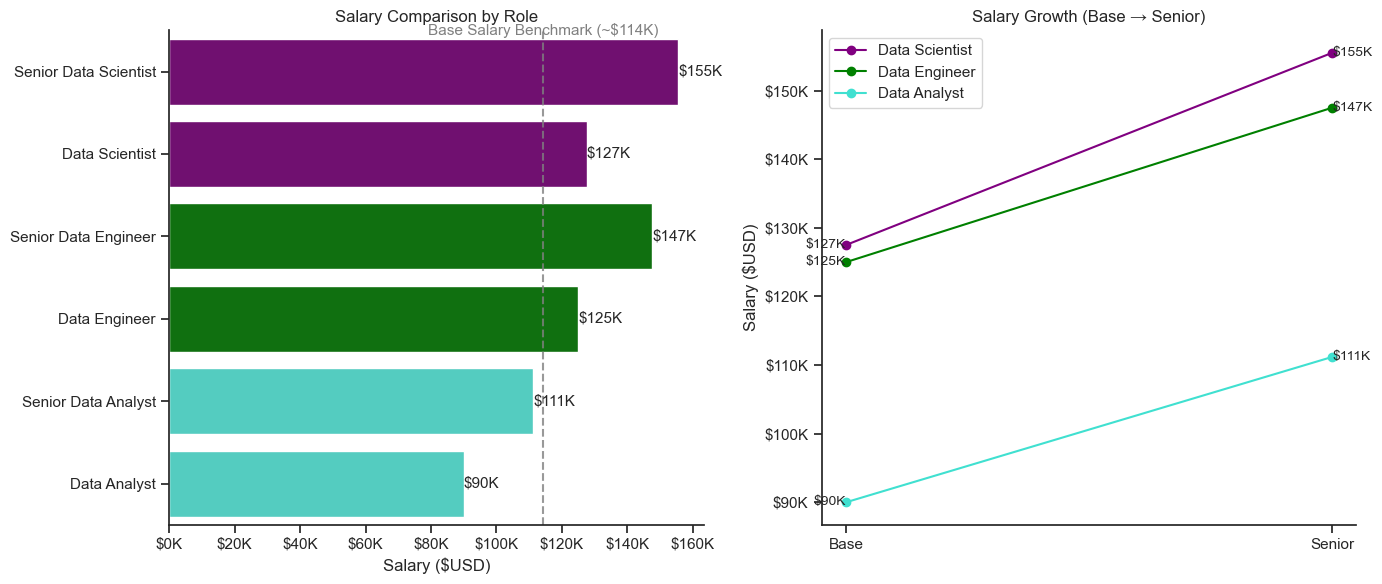

In [13]:
# Create a figure with two subplots for side-by-side comparison
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Define the display order of roles (base followed by corresponding senior roles)
order = [
    'Data Analyst', 'Senior Data Analyst',
    'Data Engineer', 'Senior Data Engineer',
    'Data Scientist', 'Senior Data Scientist'
]

# Calculate the average salary across all base (non-senior) roles for benchmarking
base_avg = df_compare[
    ~df_compare['job_title_short'].str.contains('Senior')
]['salary_year_avg'].mean()

# Define consistent colors for each role and its senior counterpart
colors0 = {
    'Data Scientist': 'purple',
    'Senior Data Scientist': 'purple',
    'Data Engineer': 'green',
    'Senior Data Engineer': 'green',
    'Data Analyst': 'turquoise',
    'Senior Data Analyst': 'turquoise'
}

# Create horizontal bar plot comparing salaries by role
sns.barplot(
    data=df_compare,
    x='salary_year_avg',
    y='job_title_short',
    hue='job_title_short',
    ax=ax[0],
    order=order,
    palette=[colors0[r] for r in df_compare['job_title_short']]
)

# Set titles and labels for the first subplot
ax[0].set_title('Salary Comparison by Role')
ax[0].set_xlabel('Salary ($USD)')
ax[0].set_ylabel('')

# Add salary labels to each bar
for container in ax[0].containers:
    ax[0].bar_label(
        container,
        labels=[f"${int(v/1000)}K" for v in container.datavalues],
        fontsize=11
    )

# Add vertical line to indicate average base salary benchmark
ax[0].axvline(base_avg, linestyle='--', color='gray', alpha=0.8)

# Annotate the benchmark line
ax[0].text(
    base_avg,
    0.99,
    f'Base Salary Benchmark (~${int(base_avg/1000)}K)',
    transform=ax[0].get_xaxis_transform(),
    ha='center',
    fontsize=11,
    color='gray'
)

# Define colors for each base role (used in line plot)
colors = {
    'Data Scientist': 'purple',
    'Data Engineer': 'green',
    'Data Analyst': 'turquoise'
}

# Invert y-axis to display roles in top-down order
ax[0].invert_yaxis()

# Define x positions for base and senior levels
x = [0, 1]

# Plot salary progression lines from base to senior roles
for _, row in df_career.iterrows():
    ax[1].plot(
        x,
        [row['base_salary'], row['senior_salary']],
        marker='o',
        color=colors[row['role']]
    )
    
    # Annotate base salary
    ax[1].text(0, row['base_salary'],
           f"${int(row['base_salary']/1000)}K",
           ha='right', va='center', fontsize=10)

    # Annotate senior salary
    ax[1].text(1, row['senior_salary'],
           f"${int(row['senior_salary']/1000)}K",
           ha='left', va='center', fontsize=10)

# Set titles and labels for the second subplot
ax[1].set_title('Salary Growth (Base → Senior)')
ax[1].set_ylabel('Salary ($USD)')
ax[1].set_xticks([0, 1])
ax[1].set_xticklabels(['Base', 'Senior'])

# Create custom legend for role categories
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], color='purple', marker='o', label='Data Scientist'),
    Line2D([0], [0], color='green', marker='o', label='Data Engineer'),
    Line2D([0], [0], color='turquoise', marker='o', label='Data Analyst')
]

ax[1].legend(handles=legend_elements)

# Format x-axis values in thousands for bar chart
from matplotlib.ticker import FuncFormatter

ax[0].xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${int(x/1000)}K')
)

# Format y-axis values in thousands for line chart
ax[1].yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: f'${int(y/1000)}K')
)

# Remove top and right spines for cleaner visualization
import seaborn as sns
sns.despine()

# Adjust layout to prevent overlap
plt.tight_layout()

## Key Insights

* SQL and Python are the most in-demand skills across all roles, forming the core technical foundation.
* Data Analysts focus more on reporting tools (Excel, Tableau, Power BI), while Engineers and Scientists require advanced skills like cloud, big data, and machine learning.
* Data Scientist roles command the highest salaries, followed by Data Engineers, with Data Analysts at the lower end.
* Salary growth from base to senior level is significant across all roles, highlighting the value of experience.
* Data Engineers and Data Scientists consistently exceed the base salary benchmark, unlike Data Analysts.
* Higher technical complexity and specialization directly correlate with higher earning potential.
